# Basic Modeling of Dark Matter

In this notebook, we will model the **Draco Dwarf Spheroidal galaxy**—one of the most Dark Matter-dominated objects in the local universe. We will compute its spatial distribution (the astrophysical **J-Factor**) and explore the particle physics behind WIMP annihilation to generate the expected, pristine gamma-ray flux arriving at Earth.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from gammapy.maps import WcsGeom, WcsNDMap
from gammapy.astro.darkmatter import (
    JFactory,
    PrimaryFlux,
    profiles,
    DarkMatterAnnihilationSpectralModel
)
import astropy.units as u
from astropy.coordinates import SkyCoord
from regions import CircleSkyRegion
import pathlib
import os

### Source definition

In [9]:
# Source position
position_dwarf_draco = SkyCoord(260.05, 57.915, frame="icrs", unit="deg")

# Distance
distance_dwarf_draco = 76 * u.kpc

# Density profile
rho_s_msun_kpc3 = 1.3e7 * (u.M_sun / u.kpc**3)  

# Units conversion
rho_s_GeV_cm3 = rho_s_msun_kpc3.to(u.GeV / u.cm**3, equivalencies=u.mass_energy())

# Define the DM profile. Check profiles.DMProfile.__subclasses__() for more profiles
draco_profile = profiles.EinastoProfile(
    r_s=0.91 * u.kpc,       
    rho_s=rho_s_GeV_cm3
)

### JFactor

Markdown
### Spatial Distribution: J-Factor and D-Factor

To calculate the expected gamma-ray flux from Dark Matter, we first need to understand its spatial distribution. 

For **Dark Matter annihilation**, we use the **J-Factor**. It represents the astrophysical component of the flux and is the integral of the Dark Matter density squared ($\rho^2$) along the line of sight ($l$) integrated over a solid angle ($\Delta \Omega$), since it requires two particles to collide:

$$J = \int_{\Delta \Omega} \int_{l.o.s.} \rho^2(l, \Omega) \, dl \, d\Omega$$

For **Dark Matter decay**, we use the **D-Factor**. This depends linearly on the density ($\rho$), as it involves single particles decaying spontaneously:

$$D = \int_{\Delta \Omega} \int_{l.o.s.} \rho(l, \Omega) \, dl \, d\Omega$$

In this section, we define the spatial parameters for the **Draco dwarf spheroidal galaxy** using an **Einasto density profile**, and compute its 2D spatial map. The calculation procedure in Gammapy is nearly identical for both cases; you only need to toggle a single parameter (`annihilation = True` or `False`) to switch between them.

/Users/alexcervino/anaconda3/envs/gammapy-dev/lib/python3.11/site-packages/numpy/lib/function_base.py:2455: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)
/Users/alexcervino/anaconda3/envs/gammapy-dev/lib/python3.11/site-packages/numpy/lib/function_base.py:2455: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)
/Users/alexcervino/anaconda3/envs/gammapy-dev/lib/python3.11/site-packages/numpy/lib/function_base.py:2455: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)
/Users/alexcervino/anaconda3/envs/gammapy-dev/lib/python3.11/site-packages/numpy/lib/function_base.py:2455: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)
/Users/alexcervino/anaconda3/envs/gammapy-dev/lib/python3.11/site-packages/numpy/lib/function_base.py:2455: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = 

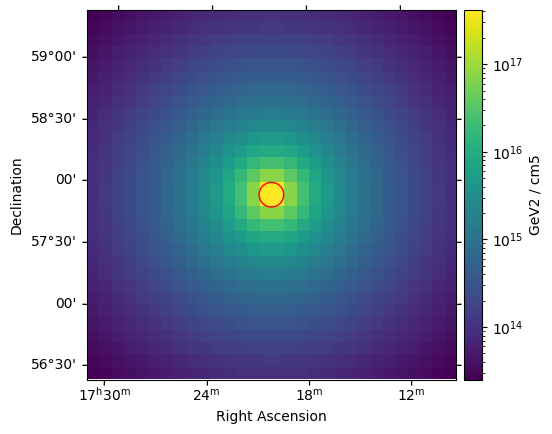

J-factor integrated on 0.1 deg circle: 1.66e+18 GeV2 / cm5
18.220880457926697


In [10]:
# Geometry map
geom_draco = WcsGeom.create(
    binsz=0.1,
    skydir=position_dwarf_draco,
    width=3.0,          
    frame="icrs"
)

# JFactory creation for ANNIHILATION
jfactory = JFactory(
    geom=geom_draco,
    profile=draco_profile,
    distance=distance_dwarf_draco,
    annihilation = True #By default is True. In case you want to compute the decay JFactor you must set it to
)

# Compute J factor
jfact_draco = jfactory.compute_jfactor()

# Map construction for plotting
jfact_map_draco = WcsNDMap(geom=geom_draco, data=jfact_draco.value, unit=jfact_draco.unit)

plt.figure()

ax = jfact_map_draco.plot(cmap="viridis", norm=LogNorm(), add_cbar=True)

# Define a region of interest (i.e., 0.1 deg circle)
sky_reg = CircleSkyRegion(center=position_dwarf_draco, radius=0.1 * u.deg)
pix_reg = sky_reg.to_pixel(wcs=geom_draco.wcs)
pix_reg.plot(ax=ax, facecolor="none", edgecolor="red", label="0.1 deg circle")
plt.show()

# Integration of JFactor within that region
total_jfact = pix_reg.to_mask().multiply(jfact_draco).sum()
print(f"J-factor integrated on 0.1 deg circle: {total_jfact:.3g}")
logtotal_jfact= np.log10(total_jfact.value)
print(logtotal_jfact)

### Region of interest
Not all telescopes have the same angular resolution, and Dark Matter halos are extended objects. To optimize our observation, we need to know how much Dark Matter signal is contained within a specific angular radius from the center of the galaxy. 
Here, we plot the integrated J-Factor as a function of the integration angle. This helps us define the optimal **Region of Interest (ROI)** for our physical analysis.

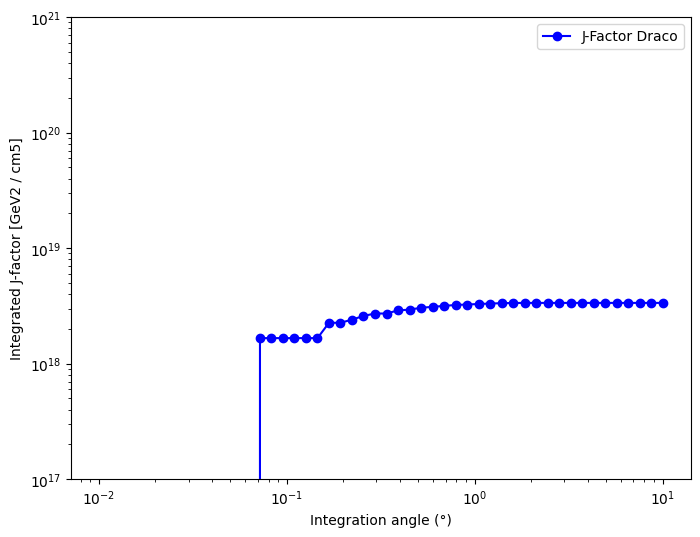

In [ ]:
# Plot integrated J Factor for several integration angles (0.01º to 10º in log scale)
angles = np.logspace(-2, 1, 50) * u.deg  

jfactor_draco_integrated = []

for theta in angles:
    sky_reg_draco = CircleSkyRegion(center=position_dwarf_draco, radius=theta)
    pix_reg_draco = sky_reg_draco.to_pixel(wcs=geom_draco.wcs)
    total_jfact_draco = pix_reg_draco.to_mask().multiply(jfact_draco).sum().value  # Extraer el valor sin unidades
    jfactor_draco_integrated.append(total_jfact_draco)

jfactor_draco_integrated = np.array(jfactor_draco_integrated)

plt.figure(figsize=(8, 6))
plt.plot(angles, jfactor_draco_integrated, marker="o", linestyle="-", color="b", label="J-Factor Draco")

plt.xscale("log")
plt.yscale("log")
plt.ylim([1e17, 1e21])

plt.xlabel("Integration angle (°)")
plt.ylabel(f"Integrated J-factor [{jfact_draco.unit}]")

plt.legend()
plt.show()

### Spectral morphology
The second half of our model is governed by particle physics. When Weakly Interacting Massive Particles (WIMPs) annihilate, they produce Standard Model particles that eventually decay or hadronize into gamma rays.

The energy spectrum of these gamma rays ($dN/dE$) depends entirely on the Dark Matter mass ($m_{\chi}$) and the dominant annihilation channel (e.g., into W/Z bosons, quarks, or leptons). Here, we plot the primary gamma-ray flux for a **10 TeV** Dark Matter particle across several typical annihilation channels.

In [ ]:
# Set the spectra data storage for Gammapy
os.environ["GAMMAPY_DATA"] = r"/Users/alexcervino/Desktop/DARKMATTER/gammapy-data/"

#In this case the spectra modelling file can be from PPPC4ID or CosmiXs
dm_path = pathlib.Path(os.environ["GAMMAPY_DATA"]) / "dark_matter_spectra"/"PPPC4DMID" / "AtProduction_gammas.dat"
print("Full DM file path =", dm_path)
print("File exists?       =", dm_path.exists())


Full DM file path = /Users/alexcervino/Desktop/DARKMATTER/gammapy-data/dark_matter_spectra/PPPC4DMID/AtProduction_gammas.dat
File exists?       = True


The filename is not defined. Therefore, the model will not be serialised correctly. To set the filename, the "template_model.filename" attribute can be used.
The filename is not defined. Therefore, the model will not be serialised correctly. To set the filename, the "template_model.filename" attribute can be used.
The filename is not defined. Therefore, the model will not be serialised correctly. To set the filename, the "template_model.filename" attribute can be used.
The filename is not defined. Therefore, the model will not be serialised correctly. To set the filename, the "template_model.filename" attribute can be used.
The filename is not defined. Therefore, the model will not be serialised correctly. To set the filename, the "template_model.filename" attribute can be used.


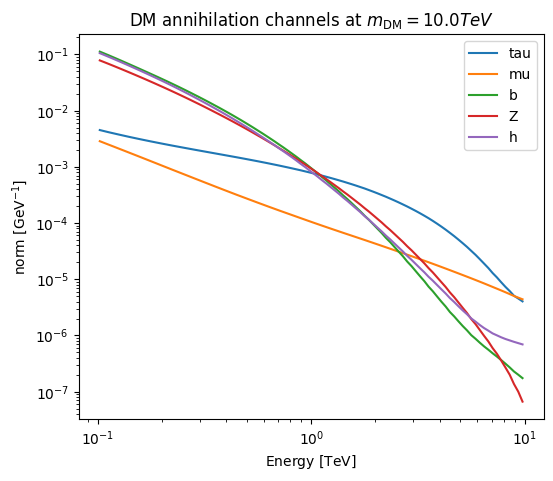

In [13]:
# Define the DM mass and channels of interest
mDM = 10.0 * u.TeV
channels = ["tau", "mu", "b", "Z", "h"] # check channels with print(fluxes.allowed_channels)

plt.figure(figsize=(6, 5))

plt.yscale("log")
plt.xlabel("Energy [TeV]")
plt.ylabel(r"dN/dE [1/GeV]")

for channel in channels:
    fluxes = PrimaryFlux(mDM=mDM, channel=channel)
    fluxes.plot(
        energy_bounds=[mDM / 100, mDM],  
        label=channel,
        yunits=u.Unit("1/GeV"),
    )

plt.title(rf"DM annihilation channels at $m_{{\mathrm{{DM}}}} = {mDM:.1f}$")
plt.legend()
plt.show()

### Expected Gamma-Ray flux map
Finally, we bring the astrophysics and the particle physics together. The total expected gamma-ray flux from Dark Matter annihilation is proportional to the product of the **J-Factor** and the integral of the **Primary Flux** over our energy range of interest (0.1 TeV to 10 TeV).

$$\Phi(>E_{min}) \propto J \times \int_{E_{min}}^{E_{max}} \frac{dN}{dE} \, dE$$

This map gives us the absolute physical flux (in cm⁻² s⁻¹) that arriving at Earth, *before* any telescope instrumental effects are applied.

The filename is not defined. Therefore, the model will not be serialised correctly. To set the filename, the "template_model.filename" attribute can be used.
/Users/alexcervino/anaconda3/envs/gammapy-dev/lib/python3.11/site-packages/numpy/lib/function_base.py:2455: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)
/Users/alexcervino/anaconda3/envs/gammapy-dev/lib/python3.11/site-packages/numpy/lib/function_base.py:2455: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)
/Users/alexcervino/anaconda3/envs/gammapy-dev/lib/python3.11/site-packages/numpy/lib/function_base.py:2455: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)
/Users/alexcervino/anaconda3/envs/gammapy-dev/lib/python3.11/site-packages/numpy/lib/function_base.py:2455: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)
/Users/alexcervino/anaconda3/e

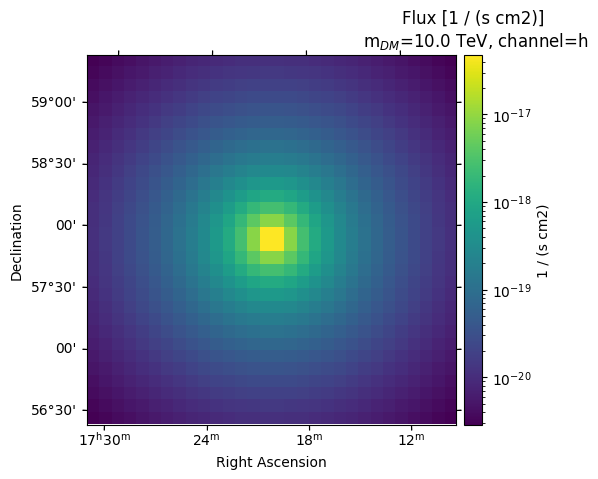

In [14]:
#This can be computed to annihilation or decay, having to change the spectral model source  to DarkMatterDecaySpectralModel
channel = "Z"
massDM = 10 * u.TeV
diff_flux = DarkMatterAnnihilationSpectralModel(mass=massDM, channel=channel)
int_flux = (
    jfact_draco * diff_flux.integral(energy_min=0.1 * u.TeV, energy_max=10 * u.TeV)
).to("cm-2 s-1")

flux_map = WcsNDMap(geom=geom_draco, data=int_flux.value, unit="cm-2 s-1")
plt.figure()
ax = flux_map.plot(cmap="viridis", norm=LogNorm(), add_cbar=True)
plt.title(
    f"Flux [{int_flux.unit}]\n m$_{{DM}}$={fluxes.mDM.to('TeV')}, channel={fluxes.channel}"
)

plt.show()